In [2]:
import os
import sys

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

import matplotlib.pyplot as plt

In [3]:
python_path = sys.executable

os.environ["PYSPARK_PYTHON"] = python_path
os.environ["PYSPARK_DRIVER_PYTHON"] = python_path

spark = (
    SparkSession.builder
    .appName("ChicagoCrime_PredictiveModeling")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)

Spark version: 4.2.0


In [4]:
BASE_PATH = r"C:\Users\HP\Documents\Big Data Technology"

PROCESSED_PATH = os.path.join(
    BASE_PATH,
    "data",
    "processed"
)

CRIME_PARQUET_PATH = os.path.join(
    PROCESSED_PATH,
    "integrated_crime_parquet"
)

integrated_crime = spark.read.parquet(CRIME_PARQUET_PATH)

print("Total records:", integrated_crime.count())
integrated_crime.printSchema()

Total records: 7784664
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: double (nullable = true)
 |-- Y Coordinate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- crime_timestamp: timestamp (nullable = true)
 |-- crime_date: date (nul

In [6]:
#Inspect the arrest target and candidate features
print("Arrest column present:", "Arrest" in integrated_crime.columns)

if "Arrest" in integrated_crime.columns:
    integrated_crime.select("Arrest").show(10, truncate=False)

Arrest column present: True
+------+
|Arrest|
+------+
|false |
|true  |
|false |
|false |
|false |
|false |
|false |
|false |
|false |
|false |
+------+
only showing top 10 rows


In [7]:
candidate_columns = [
    c for c in integrated_crime.columns
    if c in [
        "Arrest",
        "crime_year",
        "crime_month",
        "crime_hour",
        "crime_day_of_week",
        "district_clean",
        "community_area_clean",
        "latitude_clean",
        "longitude_clean",
        "rain_event",
        "snow_event",
        "precipitation",
        "avg_temperature",
        "hardship_index",
        "poverty_pct",
        "unemployment_pct",
        "per_capita_income"
    ]
]

print("Available candidate columns:")
print(candidate_columns)

Available candidate columns:
['Arrest', 'crime_month', 'crime_hour', 'crime_day_of_week', 'community_area_clean', 'latitude_clean', 'longitude_clean', 'precipitation', 'avg_temperature', 'rain_event', 'snow_event', 'poverty_pct', 'unemployment_pct', 'per_capita_income', 'hardship_index', 'crime_year', 'district_clean']


In [8]:
#Check the distribution of arrest values
integrated_crime.groupBy("Arrest").count().orderBy("Arrest").show()

+------+-------+
|Arrest|  count|
+------+-------+
| false|5749900|
|  true|2034764|
+------+-------+



In [9]:
#Create a numeric prediction label
model_data = (
    integrated_crime
    .withColumn(
        "label",
        F.when(
            F.lower(F.trim(F.col("Arrest").cast("string"))).isin(
                "true", "1", "yes", "y"
            ),
            1.0
        ).when(
            F.lower(F.trim(F.col("Arrest").cast("string"))).isin(
                "false", "0", "no", "n"
            ),
            0.0
        )
    )
)

model_data.groupBy("label").count().orderBy("label").show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|5749900|
|  1.0|2034764|
+-----+-------+



In [10]:
model_data.filter(F.col("label").isNull()).select("Arrest").distinct().show(
    50,
    truncate=False
)

+------+
|Arrest|
+------+
+------+



In [11]:
#Select available predictor columns
candidate_features = [
    "crime_year",
    "crime_month",
    "crime_hour",
    "crime_day_of_week",
    "district_clean",
    "community_area_clean",
    "latitude_clean",
    "longitude_clean",
    "rain_event",
    "snow_event",
    "precipitation",
    "avg_temperature",
    "hardship_index",
    "poverty_pct",
    "unemployment_pct",
    "per_capita_income"
]

feature_cols = [
    c for c in candidate_features
    if c in model_data.columns
]

print("Predictor columns selected:")
print(feature_cols)

Predictor columns selected:
['crime_year', 'crime_month', 'crime_hour', 'crime_day_of_week', 'district_clean', 'community_area_clean', 'latitude_clean', 'longitude_clean', 'rain_event', 'snow_event', 'precipitation', 'avg_temperature', 'hardship_index', 'poverty_pct', 'unemployment_pct', 'per_capita_income']


In [12]:
#Build and clean the modelling dataset
model_data = model_data.select(
    "label",
    *feature_cols
).filter(
    F.col("label").isNotNull()
)

for c in feature_cols:
    model_data = model_data.withColumn(
        c,
        F.col(c).cast("double")
    )

print("Rows with known arrest outcome:", model_data.count())
model_data.groupBy("label").count().orderBy("label").show()

Rows with known arrest outcome: 7784664
+-----+-------+
|label|  count|
+-----+-------+
|  0.0|5749900|
|  1.0|2034764|
+-----+-------+



In [13]:
#Check missing predictor values
missing_summary = model_data.select(
    *[
        F.sum(F.col(c).isNull().cast("long")).alias(c)
        for c in feature_cols
    ]
)

missing_summary.show(truncate=False)

+----------+-----------+----------+-----------------+--------------+--------------------+--------------+---------------+----------+----------+-------------+---------------+--------------+-----------+----------------+-----------------+
|crime_year|crime_month|crime_hour|crime_day_of_week|district_clean|community_area_clean|latitude_clean|longitude_clean|rain_event|snow_event|precipitation|avg_temperature|hardship_index|poverty_pct|unemployment_pct|per_capita_income|
+----------+-----------+----------+-----------------+--------------+--------------------+--------------+---------------+----------+----------+-------------+---------------+--------------+-----------+----------------+-----------------+
|0         |0          |0         |0                |47            |613552              |86966         |86966          |1688      |1688      |15376        |5603708        |613552        |613552     |613552          |613552           |
+----------+-----------+----------+-----------------+-------

In [14]:
#Review target class balance
label_counts = (
    model_data
    .groupBy("label")
    .count()
    .orderBy("label")
)

label_counts.show()

total_rows = model_data.count()

label_counts.withColumn(
    "percentage",
    F.round(F.col("count") / F.lit(total_rows) * 100, 2)
).show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|5749900|
|  1.0|2034764|
+-----+-------+

+-----+-------+----------+
|label|  count|percentage|
+-----+-------+----------+
|  0.0|5749900|     73.86|
|  1.0|2034764|     26.14|
+-----+-------+----------+



In [15]:
#Create a manageable stratified sample
label_values = [
    row["label"]
    for row in label_counts.collect()
]

sampling_fractions = {
    label: 0.10
    for label in label_values
}

model_sample = (
    model_data
    .sampleBy(
        "label",
        fractions=sampling_fractions,
        seed=42
    )
    .cache()
)

print("Sampled records:", model_sample.count())
model_sample.groupBy("label").count().orderBy("label").show()

Sampled records: 779047
+-----+------+
|label| count|
+-----+------+
|  0.0|575767|
|  1.0|203280|
+-----+------+



In [16]:
#Split into training and test sets
train_data, test_data = model_sample.randomSplit(
    [0.8, 0.2],
    seed=42
)

train_data = train_data.cache()
test_data = test_data.cache()

print("Training records:", train_data.count())
print("Test records:", test_data.count())

print("Training target distribution:")
train_data.groupBy("label").count().orderBy("label").show()

print("Test target distribution:")
test_data.groupBy("label").count().orderBy("label").show()

Training records: 622987
Test records: 156060
Training target distribution:
+-----+------+
|label| count|
+-----+------+
|  0.0|460534|
|  1.0|162453|
+-----+------+

Test target distribution:
+-----+------+
|label| count|
+-----+------+
|  0.0|115233|
|  1.0| 40827|
+-----+------+



In [17]:
#Calculate imputation values using training data only
imputation_values = {}

for c in feature_cols:
    median_values = train_data.approxQuantile(
        c,
        [0.5],
        0.01
    )

    if median_values:
        imputation_values[c] = float(median_values[0])
    else:
        imputation_values[c] = 0.0

print("Imputation values:")
print(imputation_values)

Imputation values:
{'crime_year': 2009.0, 'crime_month': 7.0, 'crime_hour': 14.0, 'crime_day_of_week': 4.0, 'district_clean': 10.0, 'community_area_clean': 32.0, 'latitude_clean': 41.854360882, 'longitude_clean': -87.666316176, 'rain_event': 0.0, 'snow_event': 0.0, 'precipitation': 0.0, 'avg_temperature': 128.0, 'hardship_index': 58.0, 'poverty_pct': 24.0, 'unemployment_pct': 17.1, 'per_capita_income': 17949.0}


In [18]:
train_data = train_data.fillna(imputation_values)
test_data = test_data.fillna(imputation_values)

print("Remaining training nulls:")
train_data.select(
    *[
        F.sum(F.col(c).isNull().cast("long")).alias(c)
        for c in feature_cols
    ]
).show(truncate=False)

print("Remaining test nulls:")
test_data.select(
    *[
        F.sum(F.col(c).isNull().cast("long")).alias(c)
        for c in feature_cols
    ]
).show(truncate=False)

Remaining training nulls:
+----------+-----------+----------+-----------------+--------------+--------------------+--------------+---------------+----------+----------+-------------+---------------+--------------+-----------+----------------+-----------------+
|crime_year|crime_month|crime_hour|crime_day_of_week|district_clean|community_area_clean|latitude_clean|longitude_clean|rain_event|snow_event|precipitation|avg_temperature|hardship_index|poverty_pct|unemployment_pct|per_capita_income|
+----------+-----------+----------+-----------------+--------------+--------------------+--------------+---------------+----------+----------+-------------+---------------+--------------+-----------+----------------+-----------------+
|0         |0          |0         |0                |0             |0                   |0             |0              |0         |0         |0            |0              |0             |0          |0               |0                |
+----------+-----------+----------

In [19]:
train_data.printSchema()

train_data.select("label", *feature_cols).show(5, truncate=False)

root
 |-- label: double (nullable = true)
 |-- crime_year: double (nullable = false)
 |-- crime_month: double (nullable = false)
 |-- crime_hour: double (nullable = false)
 |-- crime_day_of_week: double (nullable = false)
 |-- district_clean: double (nullable = false)
 |-- community_area_clean: double (nullable = false)
 |-- latitude_clean: double (nullable = false)
 |-- longitude_clean: double (nullable = false)
 |-- rain_event: double (nullable = false)
 |-- snow_event: double (nullable = false)
 |-- precipitation: double (nullable = false)
 |-- avg_temperature: double (nullable = false)
 |-- hardship_index: double (nullable = false)
 |-- poverty_pct: double (nullable = false)
 |-- unemployment_pct: double (nullable = false)
 |-- per_capita_income: double (nullable = false)

+-----+----------+-----------+----------+-----------------+--------------+--------------------+--------------+---------------+----------+----------+-------------+---------------+--------------+-----------+-------

In [20]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

In [21]:
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20,
    maxDepth=8,
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf])

rf_model = pipeline.fit(train_data)

print("Random Forest training completed.")

Random Forest training completed.


In [22]:
#Generate test predictions
predictions = rf_model.transform(test_data).cache()

predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.7416313307500746,0.25836866924992535]|
|0.0  |0.0       |[0.7030619484033297,0.29693805159667025]|
|0.0  |0.0       |[0.6700149014350487,0.3299850985649513] |
|0.0  |0.0       |[0.6700149014350487,0.3299850985649513] |
|0.0  |0.0       |[0.7416313307500746,0.25836866924992535]|
|0.0  |0.0       |[0.7477603777417877,0.2522396222582123] |
|0.0  |0.0       |[0.7360964770790074,0.2639035229209926] |
|0.0  |0.0       |[0.7182245577599812,0.2817754422400188] |
|0.0  |0.0       |[0.707704495944485,0.292295504055515]   |
|0.0  |0.0       |[0.7007348082419043,0.29926519175809563]|
+-----+----------+----------------------------------------+
only showing top 10 rows


In [23]:
#Create the confusion-matrix counts
predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|115233|
|  1.0|       0.0| 40823|
|  1.0|       1.0|     4|
+-----+----------+------+



In [24]:
#Calculate the confusion-matrix metrics
cm_rows = (
    predictions
    .groupBy("label", "prediction")
    .count()
    .collect()
)

cm = {
    (int(row["label"]), int(row["prediction"])): row["count"]
    for row in cm_rows
}

tn = cm.get((0, 0), 0)
fp = cm.get((0, 1), 0)
fn = cm.get((1, 0), 0)
tp = cm.get((1, 1), 0)

total = tn + fp + fn + tp

accuracy = (tp + tn) / total if total else 0
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) else 0
)

print("Confusion matrix:")
print(f"TN: {tn:,}   FP: {fp:,}")
print(f"FN: {fn:,}   TP: {tp:,}")
print()
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion matrix:
TN: 115,233   FP: 0
FN: 40,823   TP: 4

Accuracy:  0.7384
Precision: 1.0000
Recall:    0.0001
F1-score:  0.0002


In [25]:
#Calculate ROC-AUC and PR-AUC
roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

pr_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

roc_auc = roc_evaluator.evaluate(predictions)
pr_auc = pr_evaluator.evaluate(predictions)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

ROC-AUC: 0.6386
PR-AUC:  0.3832


In [26]:
#Calculate the majority-class baseline
train_class_counts = {
    int(row["label"]): row["count"]
    for row in train_data.groupBy("label").count().collect()
}

majority_class = max(train_class_counts, key=train_class_counts.get)

test_total = predictions.count()
baseline_correct = (
    predictions
    .filter(F.col("label") == float(majority_class))
    .count()
)

baseline_accuracy = baseline_correct / test_total if test_total else 0

print("Majority class predicted:", majority_class)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Random Forest accuracy: {accuracy:.4f}")

Majority class predicted: 0
Baseline accuracy: 0.7384
Random Forest accuracy: 0.7384


,feature,importance
0,crime_year,0.201924
1,poverty_pct,0.147235
2,crime_hour,0.147193
3,per_capita_income,0.117580
4,latitude_clean,0.114460
5,hardship_index,0.056890
6,community_area_clean,0.054148
7,unemployment_pct,0.050864
8,longitude_clean,0.046832
9,district_clean,0.043584


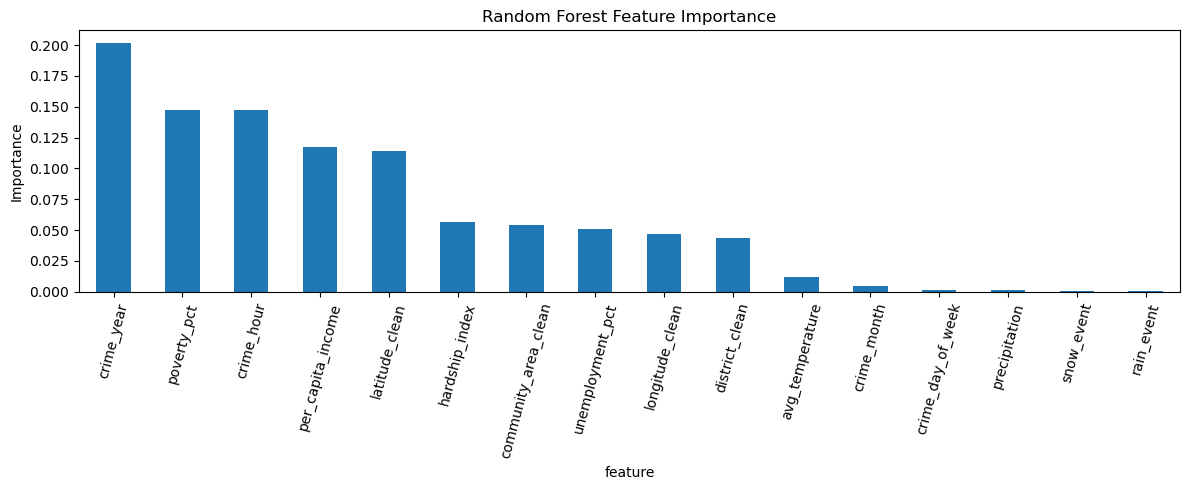

In [27]:
#View feature importance
import pandas as pd

rf_stage = rf_model.stages[-1]
importance_values = rf_stage.featureImportances.toArray()

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_values
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    figsize=(12, 5),
    rot=75,
    title="Random Forest Feature Importance"
)

plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
# Create a final evaluation summary

results_summary = spark.createDataFrame([
    ("Accuracy", float(accuracy)),
    ("Precision", float(precision)),
    ("Recall", float(recall)),
    ("F1-score", float(f1)),
    ("ROC-AUC", float(roc_auc)),
    ("PR-AUC", float(pr_auc)),
    ("Baseline Accuracy", float(baseline_accuracy))
], ["Metric", "Value"])

results_summary.show(truncate=False)

+-----------------+---------------------+
|Metric           |Value                |
+-----------------+---------------------+
|Accuracy         |0.7384147122901448   |
|Precision        |1.0                  |
|Recall           |9.797437969970853E-5 |
|F1-score         |1.9592956332198578E-4|
|ROC-AUC          |0.6385664539218773   |
|PR-AUC           |0.3832272083089889   |
|Baseline Accuracy|0.7383890811226451   |
+-----------------+---------------------+



In [29]:
RESULTS_PATH = os.path.join(
    BASE_PATH,
    "data",
    "results"
)

os.makedirs(RESULTS_PATH, exist_ok=True)

results_summary_pd = results_summary.toPandas()

metrics_file = os.path.join(
    RESULTS_PATH,
    "random_forest_metrics.csv"
)

results_summary_pd.to_csv(
    metrics_file,
    index=False
)

print("Metrics saved to:")
print(metrics_file)

Metrics saved to:
C:\Users\HP\Documents\Big Data Technology\data\results\random_forest_metrics.csv


In [30]:
importance_file = os.path.join(
    RESULTS_PATH,
    "random_forest_feature_importance.csv"
)

importance_df.to_csv(
    importance_file,
    index=False
)

print("Feature importance saved to:")
print(importance_file)

Feature importance saved to:
C:\Users\HP\Documents\Big Data Technology\data\results\random_forest_feature_importance.csv


In [31]:
MODEL_PATH = os.path.join(
    RESULTS_PATH,
    "random_forest_arrest_model"
)

rf_model.write().overwrite().save(MODEL_PATH)

print("Random Forest model saved to:")
print(MODEL_PATH)

Random Forest model saved to:
C:\Users\HP\Documents\Big Data Technology\data\results\random_forest_arrest_model


In [32]:
confusion_matrix_df = spark.createDataFrame([
    ("Actual 0", "Predicted 0", int(tn)),
    ("Actual 0", "Predicted 1", int(fp)),
    ("Actual 1", "Predicted 0", int(fn)),
    ("Actual 1", "Predicted 1", int(tp))
], ["Actual", "Prediction", "Count"])

confusion_matrix_df.show()

+--------+-----------+------+
|  Actual| Prediction| Count|
+--------+-----------+------+
|Actual 0|Predicted 0|115233|
|Actual 0|Predicted 1|     0|
|Actual 1|Predicted 0| 40823|
|Actual 1|Predicted 1|     4|
+--------+-----------+------+



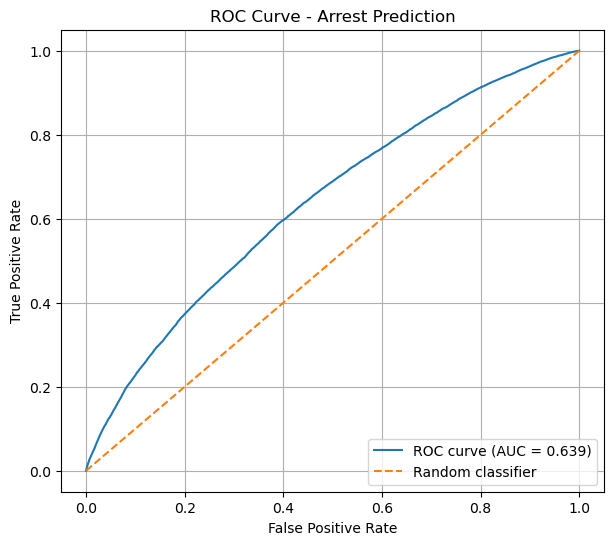

ROC-AUC: 0.6386


In [34]:
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert Spark ML probability vector to an array
roc_points = (
    predictions
    .select(
        "label",
        vector_to_array("probability")[1].alias("arrest_probability")
    )
    .toPandas()
)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    roc_points["label"],
    roc_points["arrest_probability"]
)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Arrest Prediction")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")